Title: PSL_Anomaly_winterdate_not_bc.ipynb

Purpose: Calculate the anomaly and winter time format for CMIP6 and ERA5 psl data (this is still for the non bc data)

Author: Onno Nennecke on 02.06.2025 Modified: 04.06.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import re
import glob
import time
import cftime
# import datetime
from sklearn.cluster import KMeans

# Importing functions
import Functions.grid_func as grid_func
import Functions.winter_date_func as winter_date_func


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [3]:
ts_mean_psl_pm = xr.open_dataset('/climca/people/onennecke/model_output/var_means/psl_slice/psl_mean_combined.nc')
ts_mean_psl_pm.ESM

<xarray.DataArray 'ESM' (ESM: 12)> Size: 624B
array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL',
       'Combined'], dtype='<U13')
Coordinates:
    crs       int64 8B ...
    gridtype  <U6 24B ...
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'

### Define used models

In [4]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP

Institution = ['CSIRO-ARCCSS', 'BCC', 'NCAR', 'EC-Earth-Consortium', 'NOAA-GFDL', 'NIMS-KMA', 'DKRZ', 'MRI', 'AS-RCEC', 'MOHC', 'NIMS-KMA']
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL', 'UKESM1-0-LL']
# Institution = ['CSIRO-ARCCSS', 'BCC']
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR']

scenario = 'ssp370'
# run = 'r1i1p1f1'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax', 'psl'] # List of variables
# variables = 'psl'
grid_def = '*'
version = '*'


In [5]:
def preprocess(ds, s = 25, n = 75, w = 335, e = 35):
    if e < w:
        part1 = ds.sel(lon=slice(w, 360))
        part2 = ds.sel(lon=slice(0, e))
        europe = xr.concat([part1, part2], dim="lon")
        ds = europe.sel(lat=slice(s, n))
    else:
        ds = ds.sel(lat=slice(s, n), lon=slice(w, e))
    return ds

In [4]:
ts_win_in = xr.open_dataset('/climca/people/onennecke/model_output/bias_corrected_masked/winter_data/ACCESS-CM2_r1i1p1f1_timeseries_win.nc')
# ts_win_in

In [8]:
# Takes about 
variable = 'psl'
# for ESM in ESMs:
for ESM, Inst in zip(ESMs, Institution):
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    runs = os.listdir(matching_dirs[0])
    print('Runs: ', runs)
    for run in runs:
        ESM_run = f'{ESM}_{run}'
        print('ESM_run: ', ESM_run)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') 
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
        # print('Open: ', path)
        
        # Filter out files with extensions after .nc
        files = [f for f in glob.glob(path) if f.endswith('.nc')]
        
        # Open with preprocessing (spatial filtering)
        if files:
            nc = xr.open_mfdataset(files, preprocess=preprocess)
        else:
            print("No valid .nc files found!")
            
        # Keep only the desired variable, but retain Dataset structure
        nc = nc[[variable]]
        
        # Filter to only winter months (October to March)
        # nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

        # Filter years
        nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))
        
        # Regrid the combined dataset
        regridded_ds = grid_func.regrid(nc, s = 30, n = 70, w = 340, e = 30)
        
        # Calculate anomaly
        regridded_ds['psl'] = regridded_ds['psl'] - ts_mean_psl_pm.sel(ESM = ESM)['psl']
        
        # Apply bias correction ???
        # clim_ds['psl'] = clim_ds['sfcWind'] - biases.loc[biases['ESM'] == ESM, 'bias_sfcWind'].values[0]
        
        ts_output = regridded_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
        
        # Add winter calendar
        ts_ds_win = winter_date_func.add_winter_calendar(ts_output)
        ts_win = ts_ds_win.sel(time=ts_ds_win['day_of_winter'].isin(range(1, 183)))
        old_time  = ts_win.time.values
        new_time = ts_win_in['time'].values
        ts_win = ts_win.expand_dims("ESM_run")
        old2d = old_time[np.newaxis, :]  # shape (1, ntime)
        ts_win = ts_win.assign_coords(old_time=(("ESM_run", "time"), old2d))

        if isinstance(ts_win.time.values[0], cftime.Datetime360Day):
            print('Time format is cftime.Datetime360Day')
            cut = ts_win.isel(time = slice(2, None))
            last_day = ts_win.isel(time=-1)
            long = xr.concat([cut, last_day, last_day], dim='time')
            # Fix day_of_winter and winter_season for the two new padded days
            day_of_winter = long['day_of_winter'].values
            day_of_winter[-2] = 91
            day_of_winter[-1] = 92

            winter_year = long['winter_year'].values
            winter_season = np.array([f"{y}-{d:03d}" for y, d in zip(winter_year, day_of_winter)])

            # Reassign corrected coordinates
            ts_win = long.assign_coords(
                day_of_winter=('time', day_of_winter),
                winter_season=('time', winter_season)
            )
        if ts_win.time.dtype != 'datetime64[ns]':
            print('Time format is not datetime64[ns]')
            ts_win = ts_win.assign_coords({'time': ('time', ts_win_in.time.values)})
        print(len(ts_win.sel(time=ts_win['winter_year']==2014).time.values))
        
        # Append to list for later merging
        # ds_list.append(ts_output)
        
        # # Combine all into a single dataset
        # clim_ds = xr.merge(ds_list)

        # print('Load')
        # nc.load()
        # print('Saving')
        ts_win.to_netcdf(f'/climca/people/onennecke/model_output/psl_anomaly/{ESM}_{run}_psl.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
    #     break
    # break

ESM:  ACCESS-CM2
Runs:  ['r4i1p1f1', 'r5i1p1f1', 'r1i1p1f1']
ESM_run:  ACCESS-CM2_r4i1p1f1
Run:  r4i1p1f1 Number:  1 of  3
90
Run time:  1 m 6.1 s
ESM_run:  ACCESS-CM2_r5i1p1f1
Run:  r5i1p1f1 Number:  2 of  3
90
Run time:  1 m 19.0 s
ESM_run:  ACCESS-CM2_r1i1p1f1
Run:  r1i1p1f1 Number:  3 of  3
90
Run time:  2 m 16.0 s
ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
ESM_run:  BCC-CSM2-MR_r1i1p1f1
Run:  r1i1p1f1 Number:  1 of  1
Time format is not datetime64[ns]
90
Run time:  0 m 13.2 s
ESM:  CESM2
Runs:  ['r4i1p1f1', 'r10i1p1f1', 'r11i1p1f1']
ESM_run:  CESM2_r4i1p1f1
Run:  r4i1p1f1 Number:  1 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'psl' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Time format is not datetime64[ns]
90
Run time:  0 m 51.8 s
ESM_run:  CESM2_r10i1p1f1
Run:  r10i1p1f1 Number:  2 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'psl' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Time format is not datetime64[ns]
90
Run time:  0 m 51.1 s
ESM_run:  CESM2_r11i1p1f1
Run:  r11i1p1f1 Number:  3 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'psl' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Time format is not datetime64[ns]
90
Run time:  0 m 50.6 s
ESM:  EC-Earth3
Runs:  ['r149i1p1f1', 'r6i1p1f1', 'r4i1p1f1', 'r148i1p1f1', 'r105i1p1f1', 'r9i1p1f1', 'r134i1p1f1', 'r141i1p1f1', 'r146i1p1f1', 'r15i1p1f1', 'r112i1p1f1', 'r117i1p1f1', 'r125i1p1f1', 'r113i1p1f1', 'r106i1p1f1', 'r138i1p1f1', 'r5i1p1f1', 'r137i1p1f1', 'r11i1p1f1', 'r145i1p1f1', 'r114i1p1f1', 'r120i1p1f1', 'r128i1p1f1', 'r135i1p1f1', 'r110i1p1f1', 'r129i1p1f1', 'r132i1p1f1', 'r101i1p1f1', 'r124i1p1f1', 'r127i1p1f1', 'r116i1p1f1', 'r131i1p1f1', 'r121i1p1f1', 'r142i1p1f1', 'r102i1p1f1', 'r133i1p1f1', 'r111i1p1f1', 'r140i1p1f1', 'r136i1p1f1', 'r108i1p1f1', 'r130i1p1f1', 'r150i1p1f1', 'r104i1p1f1', 'r118i1p1f1', 'r109i1p1f1', 'r143i1p1f1', 'r147i1p1f1', 'r126i1p1f1', 'r13i1p1f1', 'r119i1p1f1', 'r1i1p1f1', 'r123i1p1f1', 'r122i1p1f1', 'r115i1p1f1', 'r103i1p1f1', 'r144i1p1f1', 'r139i1p1f1', 'r107i1p1f1']
ESM_run:  EC-Earth3_r149i1p1f1
Run:  r149i1p1f1 Number:  1 of  58
90
Run time:  0 m 28.2 s
ESM_run:  EC-Earth3_r6i1p1f

### Same for ERA5

In [46]:
variable = 'slp'
# Select all files in the range 2014-2024
path = f'/climca/data/ERA5/daily/{variable}/'
year_range = (2015, 2024)
all_files = sorted(glob.glob(os.path.join(path, '*.nc')))

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

# filtered_files

In [47]:
def preprocess_ERA5(ds, s = 25, n = 75, w = 335, e = 35):
    ds = ds.reindex(lat=ds.lat[::-1])
    if e < w:
        part1 = ds.sel(lon=slice(w, 360))
        part2 = ds.sel(lon=slice(0, e))
        europe = xr.concat([part1, part2], dim="lon")
        ds = europe.sel(lat=slice(s, n))
    else:
        ds = ds.sel(lat=slice(s, n), lon=slice(w, e))
    return ds

In [50]:
ds = xr.open_mfdataset(filtered_files, combine='by_coords', preprocess=preprocess_ERA5)
# Keep only the desired variable, but retain Dataset structure
ds = ds[['var151']]
# Regrid the dataset
regridded_ds = grid_func.regrid(ds, s = 30, n = 70, w = 340, e = 30)


# Rename the variable to 'pls'
regridded_ds = regridded_ds.rename({'var151': 'psl'})

# Calculate anomaly
regridded_ds['psl'] = regridded_ds['psl'] - ts_mean_psl_pm.sel(ESM = 'ERA5')['psl']
# Assign coordinates for ESM
regridded_ds =  regridded_ds.assign_coords(run = 'hist', ESM = 'ERA5', ESM_run = 'ERA5_hist')

# Add winter calendar
ts_ds_win_ERA5 = winter_date_func.add_winter_calendar(regridded_ds)
ts_win_ERA5 = ts_ds_win_ERA5.sel(time=ts_ds_win_ERA5['day_of_winter'].isin(range(1, 183)))

old_time  = ts_win_ERA5.time.values
new_time = ts_win_in['time'].values

ts_win_ERA5 = ts_win_ERA5.expand_dims("ESM_run")
ts_win_ERA5 = ts_win_ERA5.assign_coords(time=new_time)

old2d = old_time[np.newaxis, :]  # shape (1, ntime)
ts_win_ERA5 = ts_win_ERA5.assign_coords(old_time=(("ESM_run", "time"), old2d))

ts_win_ERA5
# Save the dataset
ts_win_ERA5.to_netcdf(f'/climca/people/onennecke/model_output/psl_anomaly/ERA5_psl.nc')

### Load data again

In [51]:
path = '/climca/people/onennecke/model_output/psl_anomaly/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 1GB
Dimensions:        (ESM_run: 100, time: 1820, lat: 40, lon: 50)
Coordinates:
  * time           (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12...
  * lat            (lat) int64 320B 30 31 32 33 34 35 36 ... 64 65 66 67 68 69
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * lon            (lon) int64 400B 340 341 342 343 344 345 ... 25 26 27 28 29
    ESM            (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
  * ESM_run        (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    winter_year    (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    day_of_winter  (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    winter_season  (time) <U8 58kB dask.array<chunksize=(1820,), meta=np.ndarray>
    old_time       (ESM_run, time) object 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
Data variables:
    psl            (ESM_run, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1820, 40, 50), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

/tmp/ipykernel_1552777/1597948576.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


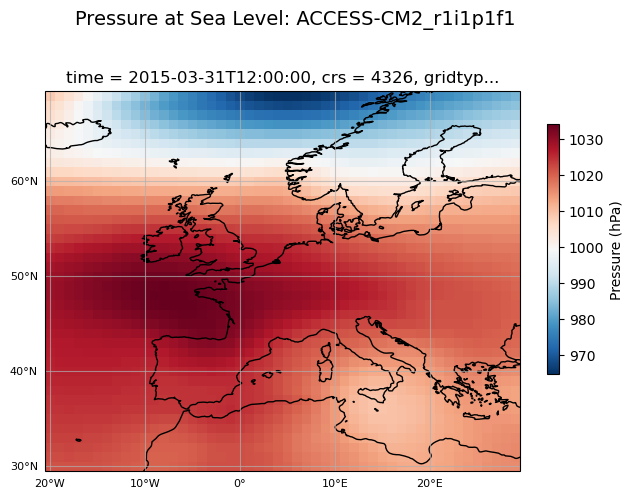

In [32]:
# Select a specific ESM run and one time step
tst = ts_datasets.sel(ESM_run='ACCESS-CM2_r1i1p1f1').isel(time=89)

# Compute vmin/vmax as Python floats
vmin_da = tst['psl'].where(tst['psl'] > 0).min() / 100
vmax_da = tst['psl'].max() / 100

# Force evaluation and extract a scalar
vmin = float(vmin_da.compute())
vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle('Pressure at Sea Level: ACCESS-CM2_r1i1p1f1', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()
